Cell 1 — Imports

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('/Users/anuragpachgade/Desktop/finml/credit-default-prediction')
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", RAW_DATA_DIR)
print("Processed dir:", PROCESSED_DATA_DIR)

Project root: /Users/anuragpachgade/Desktop/finml/credit-default-prediction
Raw data dir: /Users/anuragpachgade/Desktop/finml/credit-default-prediction/data/raw
Processed dir: /Users/anuragpachgade/Desktop/finml/credit-default-prediction/data/processed


Cell 2 - Load the CSV

In [21]:
csv_path = RAW_DATA_DIR / 'lending_club_loans.csv'

df_raw = pd.read_csv(
    csv_path,
    low_memory=False
)

print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {df_raw.shape[1]}")
print(f"Rows: {df_raw.shape[0]:,}")
df_raw.head(3)

Raw shape: (2260701, 151)
Columns: 151
Rows: 2,260,701


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


Cell 3 — Inspect the target column


In [22]:
print("All unique values in loan_status:")
print(df_raw['loan_status'].value_counts())
print(f"\nTotal rows: {df_raw.shape[0]:,}")

All unique values in loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

Total rows: 2,260,701


Cell 4 — Define the binary target

In [23]:
# Keep only terminal loan states — drop anything still active or in limbo
KEEP_STATUSES = ['Fully Paid', 'Charged Off', 'Default']

df = df_raw[df_raw['loan_status'].isin(KEEP_STATUSES)].copy()

# Binary label: 1 = default/bad, 0 = fully paid/good
df['target'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default'] else 0
)

print(f"Rows after filtering: {df.shape[0]:,}")
print(f"Rows dropped (Current, Late, etc.): {df_raw.shape[0] - df.shape[0]:,}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nDefault rate: {df['target'].mean():.2%}")

Rows after filtering: 1,345,350
Rows dropped (Current, Late, etc.): 915,351

Target distribution:
target
0    1076751
1     268599
Name: count, dtype: int64

Default rate: 19.96%


Cell 5 — Class balance visualization

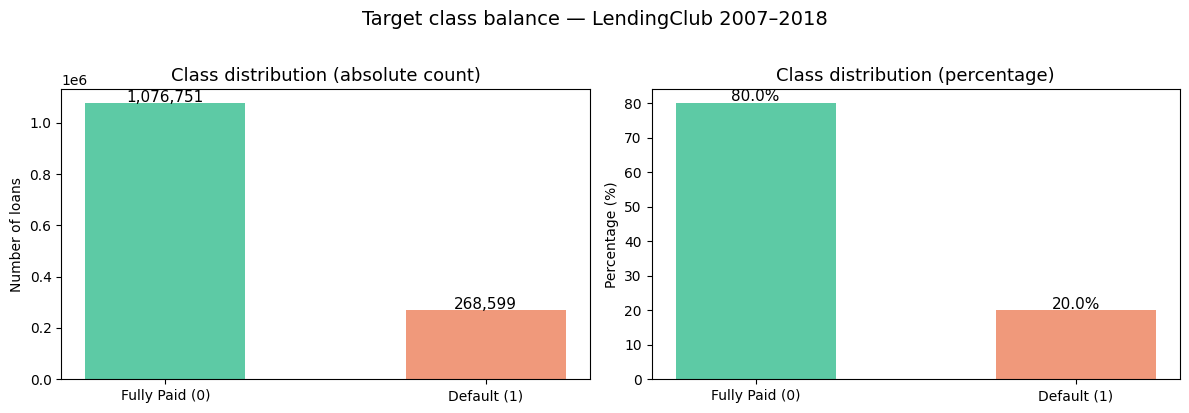


Class imbalance ratio: 4.0:1 (paid:default)
→ Will handle with scale_pos_weight in XGBoost or SMOTE during modeling


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['target'].value_counts()
colors = ['#5DCAA5', '#F0997B']
axes[0].bar(['Fully Paid (0)', 'Default (1)'], counts.values, color=colors, width=0.5)
axes[0].set_title('Class distribution (absolute count)', fontsize=13)
axes[0].set_ylabel('Number of loans')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=11)

# Percentage plot
pcts = df['target'].value_counts(normalize=True) * 100
axes[1].bar(['Fully Paid (0)', 'Default (1)'], pcts.values, color=colors, width=0.5)
axes[1].set_title('Class distribution (percentage)', fontsize=13)
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(pcts.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Target class balance — LendingClub 2007–2018', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio: {counts[0]/counts[1]:.1f}:1 (paid:default)")
print("→ Will handle with scale_pos_weight in XGBoost or SMOTE during modeling")

Cell 4 — Define the binary target

In [26]:
# Keep only terminal loan states — drop anything still active or in limbo
KEEP_STATUSES = ['Fully Paid', 'Charged Off', 'Default']

df = df_raw[df_raw['loan_status'].isin(KEEP_STATUSES)].copy()

# Binary label: 1 = default/bad, 0 = fully paid/good
df['target'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default'] else 0
)

print(f"Rows after filtering: {df.shape[0]:,}")
print(f"Rows dropped (Current, Late, etc.): {df_raw.shape[0] - df.shape[0]:,}")
print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nDefault rate: {df['target'].mean():.2%}")

Rows after filtering: 1,345,350
Rows dropped (Current, Late, etc.): 915,351

Target distribution:
target
0    1076751
1     268599
Name: count, dtype: int64

Default rate: 19.96%


Cell 5 — Class balance visualization

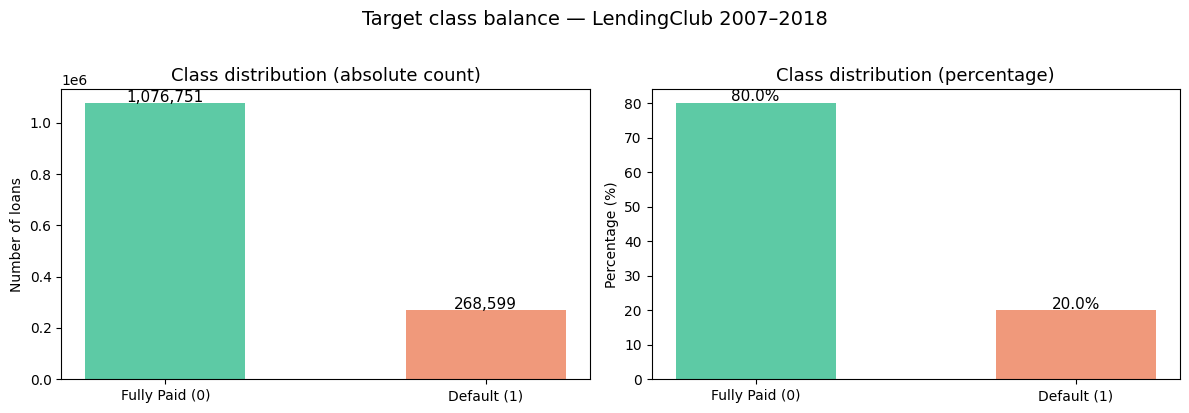


Class imbalance ratio: 4.0:1 (paid:default)
→ Will handle with scale_pos_weight in XGBoost or SMOTE during modeling


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['target'].value_counts()
colors = ['#5DCAA5', '#F0997B']
axes[0].bar(['Fully Paid (0)', 'Default (1)'], counts.values, color=colors, width=0.5)
axes[0].set_title('Class distribution (absolute count)', fontsize=13)
axes[0].set_ylabel('Number of loans')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=11)

# Percentage plot
pcts = df['target'].value_counts(normalize=True) * 100
axes[1].bar(['Fully Paid (0)', 'Default (1)'], pcts.values, color=colors, width=0.5)
axes[1].set_title('Class distribution (percentage)', fontsize=13)
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(pcts.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle('Target class balance — LendingClub 2007–2018', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nClass imbalance ratio: {counts[0]/counts[1]:.1f}:1 (paid:default)")
print("→ Will handle with scale_pos_weight in XGBoost or SMOTE during modeling")

Cell 6 — Full column inventory

In [28]:
# See all columns with dtype and null count
col_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
})

print(f"Total columns: {len(col_summary)}")
print("\nColumns with >50% missing (candidates for dropping):")
print(col_summary[col_summary['null_pct'] > 50].sort_values('null_pct', ascending=False))# See all columns with dtype and null count
col_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique()
})

print(f"Total columns: {len(col_summary)}")
print("\nColumns with >50% missing (candidates for dropping):")
print(col_summary[col_summary['null_pct'] > 50].sort_values('null_pct', ascending=False))

Total columns: 152

Columns with >50% missing (candidates for dropping):
                                              dtype  null_count  null_pct  \
member_id                                   float64     1345350    100.00   
next_pymnt_d                                 object     1345310    100.00   
orig_projected_additional_accrued_interest  float64     1341589     99.72   
hardship_end_date                            object     1339594     99.57   
hardship_type                                object     1339594     99.57   
hardship_reason                              object     1339594     99.57   
hardship_status                              object     1339594     99.57   
hardship_amount                             float64     1339594     99.57   
hardship_start_date                          object     1339594     99.57   
deferral_term                               float64     1339594     99.57   
payment_plan_start_date                      object     1339594     99.57   
har

Cell 7 — Leakage audit (the most important cell)
This separates a professional project from a Kaggle notebook. These columns exist in the dataset but are only known after the loan has already defaulted or been paid — using them would let the model "cheat."

In [29]:
# ── POST-ORIGINATION COLUMNS (DROP THESE — they leak the outcome) ──────────
POST_ORIGINATION = [
    # Payment activity columns — only exist after loan is active
    'total_pymnt',             # total amount paid to date
    'total_pymnt_inv',         # total paid by investors
    'total_rec_prncp',         # principal received
    'total_rec_int',           # interest received
    'total_rec_late_fee',      # late fees received
    'recoveries',              # post-default recovery amount
    'collection_recovery_fee', # fee on recovery
    'last_pymnt_amnt',         # last payment amount
    'last_pymnt_d',            # last payment date
    'next_pymnt_d',            # next scheduled payment date

    # Delinquency history recorded AFTER origination
    'out_prncp',               # remaining principal
    'out_prncp_inv',           # remaining principal (investor share)
    'total_il_high_credit_limit',

    # Account status at time of data pull (not at origination)
    'last_credit_pull_d',      # date of last credit pull
    'last_fico_range_high',    # FICO at last pull (not at origination)
    'last_fico_range_low',

    # Direct outcome encodings
    'loan_status',             # this IS the target — never use as feature
    'charged_off_jointly',
]

# ── TARGET COLUMN (keep separately) ─────────────────────────────────────────
TARGET_COL = 'target'

# ── PRE-ORIGINATION COLUMNS (KEEP THESE — known at application time) ────────
PRE_ORIGINATION = [
    'loan_amnt',          # requested loan amount
    'funded_amnt',        # funded amount
    'term',               # 36 or 60 months
    'int_rate',           # interest rate assigned
    'installment',        # monthly payment
    'grade',              # LC assigned grade A-G
    'sub_grade',          # LC assigned sub-grade
    'emp_title',          # job title (high cardinality)
    'emp_length',         # employment length
    'home_ownership',     # RENT / OWN / MORTGAGE
    'annual_inc',         # self-reported annual income
    'verification_status',# income verification status
    'issue_d',            # loan issue date (use for temporal split)
    'purpose',            # loan purpose category
    'title',              # loan title (free text — drop later)
    'zip_code',           # first 3 digits of zip
    'addr_state',         # US state
    'dti',                # debt-to-income ratio
    'delinq_2yrs',        # delinquencies in past 2 years
    'earliest_cr_line',   # date of earliest credit line
    'fico_range_low',     # FICO score at origination (low)
    'fico_range_high',    # FICO score at origination (high)
    'inq_last_6mths',     # credit inquiries last 6 months
    'mths_since_last_delinq', # months since last delinquency
    'open_acc',           # number of open credit lines
    'pub_rec',            # number of derogatory public records
    'revol_bal',          # revolving balance
    'revol_util',         # revolving line utilization rate
    'total_acc',          # total credit lines ever
    'initial_list_status',# w (whole) or f (fractional)
    'application_type',   # individual or joint
    'annual_inc_joint',   # joint income (if applicable)
    'dti_joint',          # joint DTI (if applicable)
]

# ── AMBIGUOUS COLUMNS (need judgment) ───────────────────────────────────────
AMBIGUOUS = [
    'pymnt_plan',   # whether a payment plan was put in place — could be post-origination
    'hardship_flag',# hardship flag — definitely post-origination, DROP
    'debt_settlement_flag', # post-origination, DROP
]

print("POST-ORIGINATION (dropping):", len(POST_ORIGINATION), "columns")
print("PRE-ORIGINATION (keeping):", len(PRE_ORIGINATION), "columns")
print("AMBIGUOUS (review):", len(AMBIGUOUS), "columns")

# Check which of our flagged columns actually exist in this dataset
existing_post = [c for c in POST_ORIGINATION if c in df.columns]
existing_pre  = [c for c in PRE_ORIGINATION  if c in df.columns]
missing_pre   = [c for c in PRE_ORIGINATION  if c not in df.columns]

print(f"\nPost-origination columns found in dataset: {len(existing_post)}")
print(f"Pre-origination columns found in dataset: {len(existing_pre)}")
if missing_pre:
    print(f"Pre-origination columns NOT in dataset (may be named differently): {missing_pre}")

POST-ORIGINATION (dropping): 18 columns
PRE-ORIGINATION (keeping): 33 columns
AMBIGUOUS (review): 3 columns

Post-origination columns found in dataset: 17
Pre-origination columns found in dataset: 33


Cell 8 — Drop leakage columns and build clean dataframe

In [31]:
cols_to_drop = existing_post + ['title', 'hardship_flag', 'debt_settlement_flag', 'pymnt_plan']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_clean = df.drop(columns=cols_to_drop)

# Remove 'title' from existing_pre since we just dropped it
existing_pre_final = [c for c in existing_pre if c in df_clean.columns]

df_clean = df_clean[existing_pre_final + [TARGET_COL]].copy()

print(f"Shape after leakage removal: {df_clean.shape}")
print(f"Columns remaining: {df_clean.shape[1]}")
print(f"\nFinal feature columns:")
for col in df_clean.columns:
    if col != TARGET_COL:
        print(f"  {col:35s}  dtype: {df_clean[col].dtype}   nulls: {df_clean[col].isnull().sum():,}")

Shape after leakage removal: (1345350, 33)
Columns remaining: 33

Final feature columns:
  loan_amnt                            dtype: float64   nulls: 0
  funded_amnt                          dtype: float64   nulls: 0
  term                                 dtype: object   nulls: 0
  int_rate                             dtype: float64   nulls: 0
  installment                          dtype: float64   nulls: 0
  grade                                dtype: object   nulls: 0
  sub_grade                            dtype: object   nulls: 0
  emp_title                            dtype: object   nulls: 85,791
  emp_length                           dtype: object   nulls: 78,516
  home_ownership                       dtype: object   nulls: 0
  annual_inc                           dtype: float64   nulls: 0
  verification_status                  dtype: object   nulls: 0
  issue_d                              dtype: object   nulls: 0
  purpose                              dtype: object   nulls: 0


Cell 9 — Parse dates and create temporal split column

In [32]:
# Parse issue_d for temporal splitting later
df_clean['issue_d'] = pd.to_datetime(df_clean['issue_d'], format='%b-%Y')
df_clean['issue_year'] = df_clean['issue_d'].dt.year

print("Loan distribution by year:")
year_counts = df_clean.groupby('issue_year').agg(
    total_loans=('target', 'count'),
    default_rate=('target', 'mean')
).round(4)
year_counts['default_rate_pct'] = (year_counts['default_rate'] * 100).round(2)
print(year_counts.to_string())

print("\nTemporal split plan:")
print("  Train : 2007–2015  →", df_clean[df_clean['issue_year'] <= 2015].shape[0], "loans")
print("  Val   : 2016       →", df_clean[df_clean['issue_year'] == 2016].shape[0], "loans")
print("  Test  : 2017–2018  →", df_clean[df_clean['issue_year'] >= 2017].shape[0], "loans")

Loan distribution by year:
            total_loans  default_rate  default_rate_pct
issue_year                                             
2007                251        0.1793             17.93
2008               1562        0.1581             15.81
2009               4716        0.1260             12.60
2010              11536        0.1289             12.89
2011              21721        0.1518             15.18
2012              53367        0.1620             16.20
2013             134804        0.1560             15.60
2014             223103        0.1845             18.45
2015             375546        0.2019             20.19
2016             293105        0.2329             23.29
2017             169321        0.2313             23.13
2018              56318        0.1576             15.76

Temporal split plan:
  Train : 2007–2015  → 826606 loans
  Val   : 2016       → 293105 loans
  Test  : 2017–2018  → 225639 loans


Cell 10 — Save cleaned data to disk

In [ ]:
output_path = PROCESSED_DATA_DIR / 'loans_clean.parquet'
df_clean.to_parquet(output_path, index=False)

print(f"Saved to: {output_path}")
print(f"File size: {output_path.stat().st_size / 1e6:.1f} MB")
print(f"\nFinal dataset summary:")
print(f"  Rows    : {df_clean.shape[0]:,}")
print(f"  Features: {df_clean.shape[1] - 1}")  # exclude target
print(f"  Target  : {df_clean['target'].mean():.2%} default rate")
print(f"\nDay 2 complete. Load loans_clean.parquet in all subsequent notebooks.")

Saved to: /Users/anuragpachgade/Desktop/finml/credit-default-prediction/data/processed/loans_clean.parquet
File size: 46.8 MB

Final dataset summary:
  Rows    : 1,345,350
  Features: 33
  Target  : 19.96% default rate

Day 2 complete. Load loans_clean.parquet in all subsequent notebooks.
